In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [46]:
df = pd.read_csv(
    "../Dataset/Cleaned/online_retail_cleaned.csv",
    dtype={"Invoice": str},
    low_memory=False
)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [47]:
rfm_df = df.dropna(subset=["Customer ID"]).copy()

print(rfm_df.shape)

(400947, 9)


In [48]:
analysis_date = rfm_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(analysis_date)

2010-12-10 20:01:00


In [49]:
rfm = rfm_df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [50]:
rfm.describe()

,Recency,Frequency,Monetary
count,4314.000000,4314.000000,4314.000000
mean,91.269124,4.454103,2039.460766
std,96.943482,8.168658,8909.797773
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.105000
50%,53.000000,2.000000,700.405000
75%,136.000000,5.000000,1713.297500
max,374.000000,205.000000,349164.350000


In [51]:
top_customers = rfm.sort_values("Monetary", ascending=False).head(10)

top_customers

,Recency,Frequency,Monetary
Customer ID,,,
18102.0,1,89,349164.35
14646.0,10,78,248396.50
14156.0,7,102,196549.74
14911.0,1,205,152121.22
13694.0,9,94,131443.19
17511.0,3,31,84541.17
15061.0,3,86,83284.38
16684.0,15,27,80489.21
16754.0,8,29,65500.07


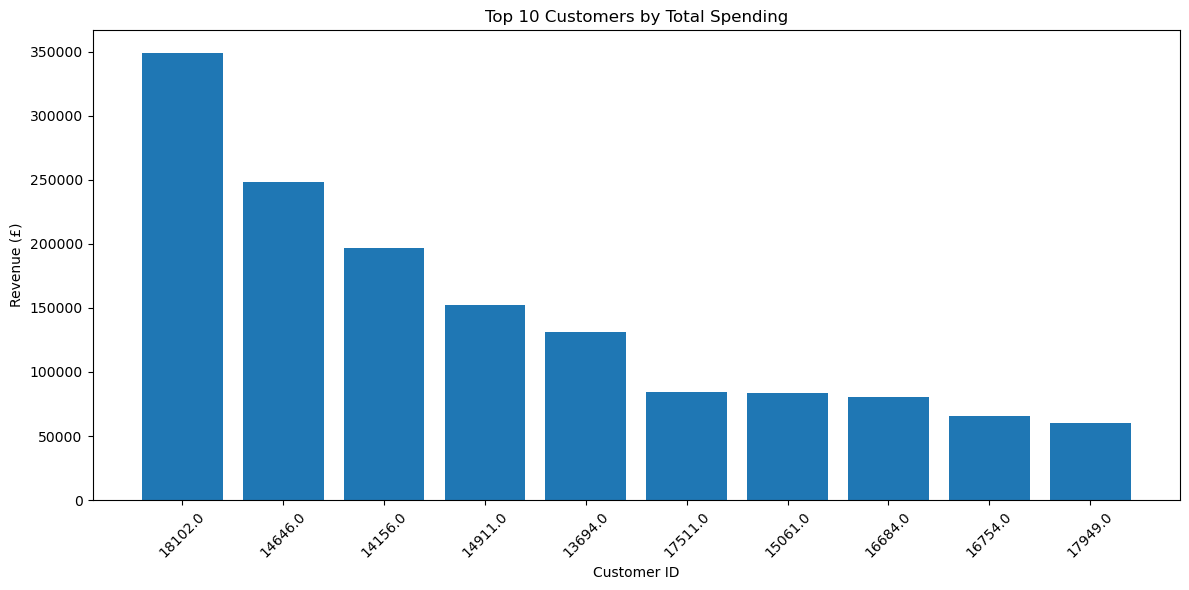

In [52]:
plt.figure(figsize=(12,6))

plt.bar(
    top_customers.index.astype(str),
    top_customers["Monetary"]
)

plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [53]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

In [54]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [55]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [56]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,165,11,372.86,2,5,2,252
12347.0,3,2,1323.32,5,2,4,524
12348.0,74,1,222.16,2,1,1,211
12349.0,43,3,2671.14,3,3,5,335
12351.0,11,1,300.93,5,1,2,512


In [57]:
def customer_segment(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 4:
        return "Loyal Customers"

    elif row["R_Score"] >= 4 and row["F_Score"] <= 2:
        return "Potential Loyalists"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 4:
        return "At Risk"

    else:
        return "Others"

In [58]:
rfm["Segment"] = rfm.apply(customer_segment, axis=1)

In [59]:
segment_counts = rfm["Segment"].value_counts()

segment_counts

Segment
Others                 2222
Champions               926
Loyal Customers         479
Potential Loyalists     366
At Risk                 321
Name: count, dtype: int64

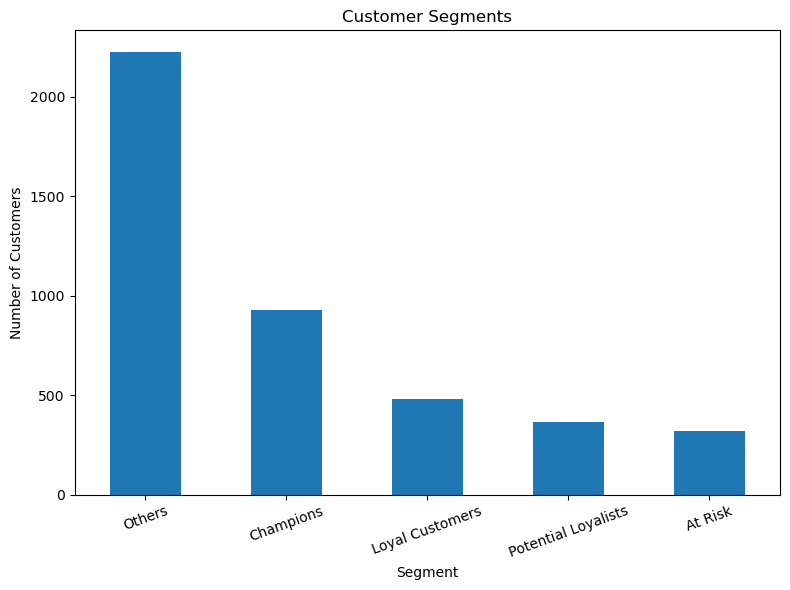

In [60]:
plt.figure(figsize=(8, 6))

segment_counts.plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [61]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
       .sum()
       .sort_values(ascending=False)
)

segment_revenue

Segment
Champions              5712430.697
Others                 1327896.704
Loyal Customers         845933.702
At Risk                 729040.781
Potential Loyalists     182931.860
Name: Monetary, dtype: float64

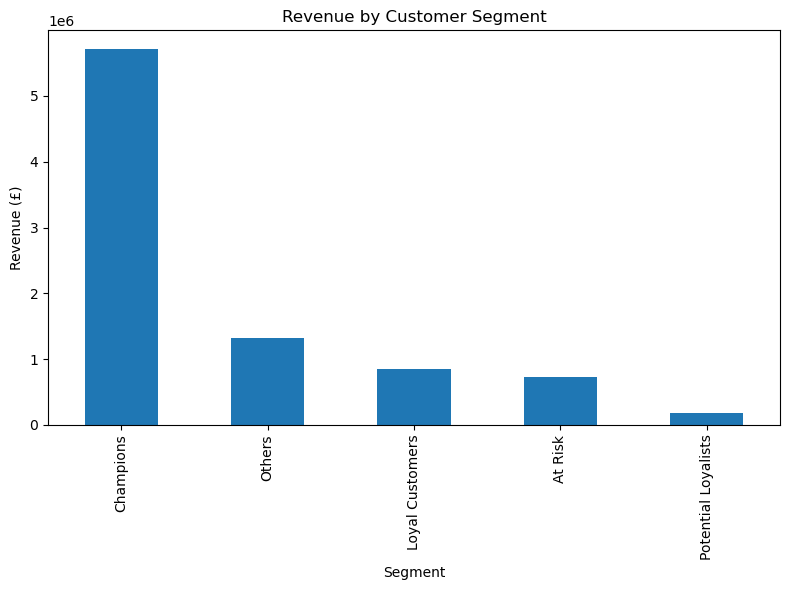

In [62]:
plt.figure(figsize=(8, 6))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue (£)")

plt.tight_layout()

plt.show()

In [64]:
rfm.to_csv(
    "../Dataset/Cleaned/customer_rfm.csv",
    index=True
)

In [65]:
segment_percentage = (
    rfm["Segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_percentage

Segment
Others                 51.51
Champions              21.46
Loyal Customers        11.10
Potential Loyalists     8.48
At Risk                 7.44
Name: proportion, dtype: float64

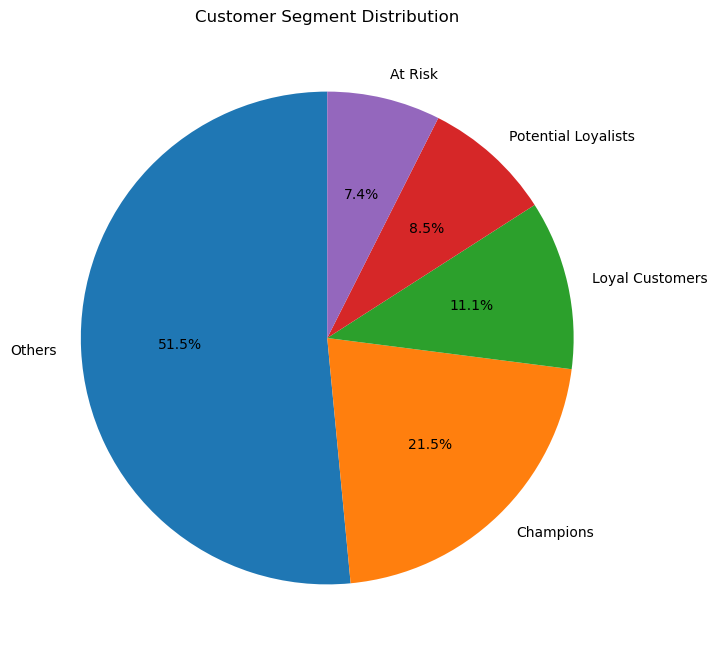

In [66]:
plt.figure(figsize=(8,8))

plt.pie(
    segment_percentage,
    labels=segment_percentage.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Segment Distribution")

plt.show()

In [67]:
df_sql = df.copy()

# Replace missing Customer IDs with NULL-friendly value
df_sql["Customer ID"] = df_sql["Customer ID"].fillna(0).astype(int)

df_sql.to_csv(
    "../Dataset/Cleaned/online_retail_sql.csv",
    index=False
)